In [2]:
import numpy as np
import matplotlib.pyplot as plt
from regions import Regions
import regions
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astroquery.svo_fps import SvoFps

from dust_extinction.averages import CT06_MWGC

from smart_plotters.jwst_plots import JWSTCatalog, make_cat_use, make_brick_cat
from smart_plotters.cutout_plot import get_cutout_405, get_cutout_jwst_ice
#import smart_plotters.co_ice as co_map
from smart_plotters import cmd_plot

        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]


In [3]:
cat_use = make_cat_use()

In [28]:
def get_rc_sel_mask(cat):
    x = np.linspace(0, 2.5, 10)
    
    x0 = 0.52
    mask_x0_left = cat.color('f182m', 'f212n') > x0

    y0 = 14.8
    mask_above_y0 = cat.band('f182m') > y0
    mask_rc = mask_above_y0 & mask_x0_left

    pt1 = (0.5, 14.3)
    pt2 = (2.0, 20.)
    y1 = (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (x - pt1[0]) + pt1[1]
    mask_below_y1 = cat.band('f182m') > ( (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (cat.color('f182m', 'f212n') - pt1[0]) + pt1[1] )
    mask_rc = mask_below_y1 & mask_rc

    pt1 = (0.5, 15.5)
    pt2 = (2.0, 20.9)
    y2 = (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (x - pt1[0]) + pt1[1]
    mask_above_y2 = cat.band('f182m') < ( (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (cat.color('f182m', 'f212n') - pt1[0]) + pt1[1] )
    mask_rc = mask_rc & mask_above_y2

    return mask_rc
cat_rc = JWSTCatalog(cat_use.catalog[get_rc_sel_mask(cat_use)])

In [4]:
# for each filter in the catalog, check the emag. If it is greater than 0.05, then mask every column related to that filter
bands = cat_use.filters
for band in bands:
    mask = cat_use.catalog['emag_ab_' + band] < 0.05
    for col in cat_use.catalog.colnames:
        if band in col:
            try: 
                cat_use.catalog[col][~mask] = np.nan
            except:
                continue

In [5]:
fn_405 = '/orange/adamginsburg/jwst/cloudc/images/jw02221-o002_t001_nircam_clear-f405n-merged_i2d.fits'
fn_410 = '/orange/adamginsburg/jwst/cloudc/images/jw02221-o002_t001_nircam_clear-f410m-merged_i2d.fits'
fn_466 = '/orange/adamginsburg/jwst/cloudc/images/jw02221-o002_t001_nircam_clear-f466n-merged_i2d.fits'
fn_187 = '/orange/adamginsburg/jwst/cloudc/images/jw02221-o002_t001_nircam_clear-f187n-merged_i2d.fits'
fn_182 = '/orange/adamginsburg/jwst/cloudc/images/jw02221-o002_t001_nircam_clear-f182m-merged_i2d.fits'
fn_212 = '/orange/adamginsburg/jwst/cloudc/images/jw02221-o002_t001_nircam_clear-f212n-merged_i2d.fits'


In [6]:
image_filenames = {
    'f187n': fn_187,
    'f405n': fn_405,
    'f410m': fn_410,
    'f466n': fn_466,
    'f182m': fn_182,
    'f212n': fn_212,
}

In [7]:
def get_line_excess(catalog, narrow, wide):
    ww_narrow = WCS(fits.getheader(image_filenames[narrow], ext=('SCI', 1)))
    ww_wide = WCS(fits.getheader(image_filenames[wide], ext=('SCI', 1)))
    data_narrow = (catalog['flux_' + narrow] * u.MJy/u.sr * ww_narrow.proj_plane_pixel_area()).to(u.Jy)
    data_wide = (catalog['flux_' + wide] * u.MJy/u.sr * ww_wide.proj_plane_pixel_area()).to(u.Jy)

    wavelength_table_narrow = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    wavelength_table_wide = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')

    waves_wide = wavelength_table_wide['Wavelength']
    trans_narrow = np.interp(waves_wide, wavelength_table_narrow['Wavelength'], wavelength_table_narrow['Transmission'])
    trans_wide = wavelength_table_wide['Transmission']


    fractional_bandwidth = ( (trans_wide/trans_wide.max()) * (trans_narrow/trans_narrow.max()) ).sum() / (trans_wide/trans_wide.max()).sum()
    print(f'Fractional bandwidth: {fractional_bandwidth}')
    if fractional_bandwidth == 1:
        print("The filters either have no overlap or are identical. Exiting")
        return


    wide_minus_narrow = (data_wide - data_narrow * fractional_bandwidth) / (1-fractional_bandwidth)
    #return wide_minus_narrow

    narrow_minus_wide = data_narrow - wide_minus_narrow
    #narrow_minus_wide = (data_narrow - data_wide * fractional_bandwidth) / (1-fractional_bandwidth)
    return np.array(narrow_minus_wide)

In [8]:
bra_excess = get_line_excess(cat_use.catalog, 'f405n', 'f410m')
paa_excess = get_line_excess(cat_use.catalog, 'f187n', 'f182m')

Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.09655212419159323


In [9]:
av_values = cat_use.get_Av('f182m', 'f212n', ext=CT06_MWGC())

In [10]:
wl_paa = 1.87 * u.micron
wl_bra = 4.05 * u.micron

In [11]:
ext = CT06_MWGC()

paa_excess_dered = paa_excess * 10**(ext(wl_paa) * av_values / 2.5) / 10**(0.0258 * av_values)
bra_excess_dered = bra_excess * 10**(ext(wl_bra) * av_values / 2.5) / 10**(-0.0136 * av_values)

Text(0, 0.5, 'Bra excess (Jy)')

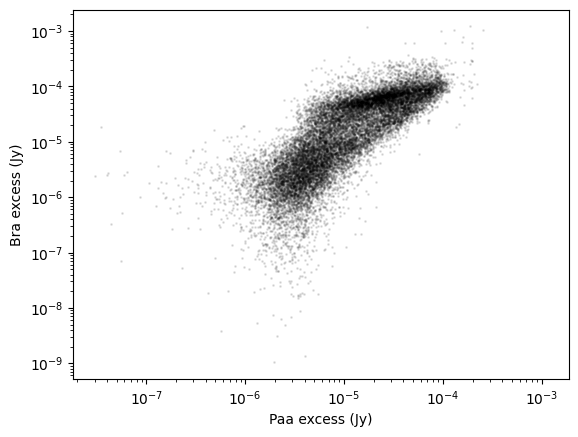

In [12]:
ax = plt.subplot(111)
ax.scatter(paa_excess, bra_excess, s=1, alpha=0.1, color='k')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Paa excess (Jy)')
ax.set_ylabel('Bra excess (Jy)')

Text(0, 0.5, 'Bra excess (Jy)')

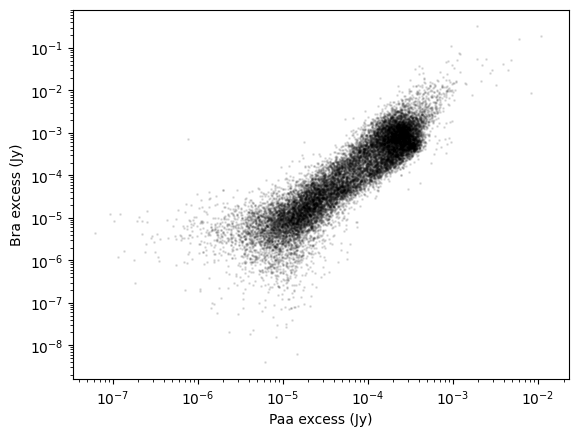

In [13]:
ax = plt.subplot(111)
ax.scatter(paa_excess_dered, bra_excess_dered, s=1, alpha=0.1, color='k')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Paa excess (Jy)')
ax.set_ylabel('Bra excess (Jy)')

Text(0, 0.5, 'Dereddened Bra excess (Jy)')

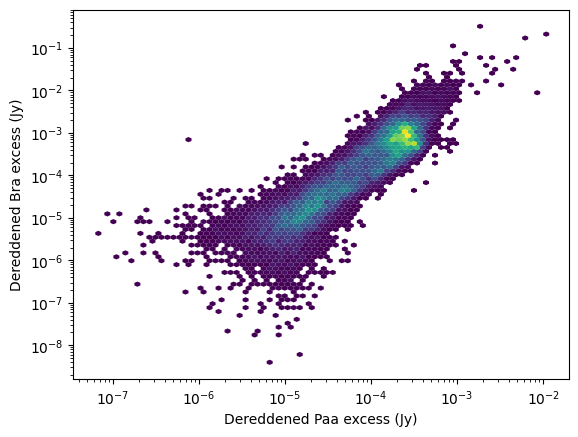

In [14]:
ax = plt.subplot(111)
mask = (bra_excess_dered > 0) & (paa_excess_dered > 0)
ax.hexbin(paa_excess_dered[mask], bra_excess_dered[mask], gridsize=75, yscale='log', xscale='log', cmap='viridis', mincnt=1, edgecolors='none')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Dereddened Paa excess (Jy)')
ax.set_ylabel('Dereddened Bra excess (Jy)')

In [15]:
from astropy.visualization import simple_norm

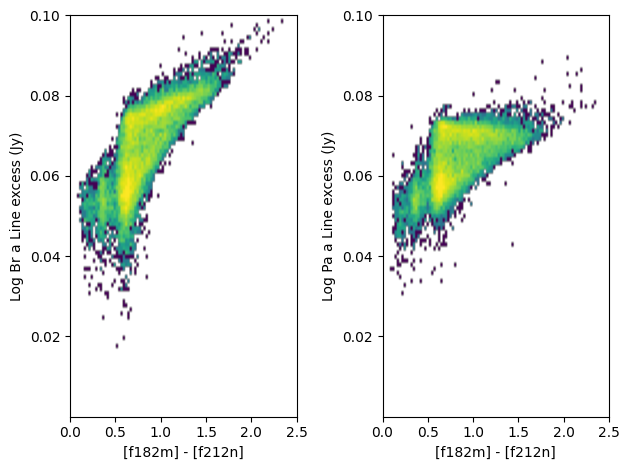

In [16]:
ax = plt.subplot(121)
mask = (bra_excess_dered > 0) & (paa_excess_dered > 0) & (cat_use.catalog['emag_ab_f182m'] < 0.05) & (cat_use.catalog['emag_ab_f212n'] < 0.05)
xedges = np.linspace(0, 2.5, 100)
yedges = np.logspace(-10, -1, 100)
h2d, xedges, yedges = np.histogram2d(cat_use.color('f182m', 'f212n')[mask], bra_excess_dered[mask], bins=(xedges, yedges))
h2d[h2d == 0] = np.nan
norm = simple_norm(h2d.T, 'log', percent=99)
plt.imshow(h2d.T, origin='lower', aspect='auto', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], norm=norm, cmap='viridis')
#ax.set_yscale('log')
ax.set_xlabel('[f182m] - [f212n]')
ax.set_ylabel('Log Br a Line excess (Jy)')

ax = plt.subplot(122)
xedges = np.linspace(0, 2.5, 100)
yedges = np.logspace(-10, -1, 100)
h2d, xedges, yedges = np.histogram2d(cat_use.color('f182m', 'f212n')[mask], paa_excess_dered[mask], bins=(xedges, yedges))
h2d[h2d == 0] = np.nan
norm = simple_norm(h2d.T, 'log', percent=99)
plt.imshow(h2d.T, origin='lower', aspect='auto', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], norm=norm, cmap='viridis')
#ax.set_yscale('log')
ax.set_xlabel('[f182m] - [f212n]')
ax.set_ylabel('Log Pa a Line excess (Jy)')

plt.tight_layout()

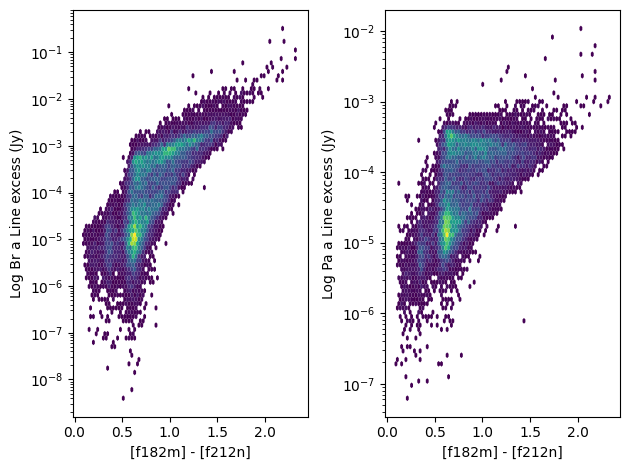

In [17]:
ax = plt.subplot(121)
mask = (bra_excess_dered > 0) & (paa_excess_dered > 0) & (cat_use.catalog['emag_ab_f182m'] < 0.05) & (cat_use.catalog['emag_ab_f212n'] < 0.05)

ax.hexbin(cat_use.color('f182m', 'f212n')[mask], bra_excess_dered[mask], gridsize=75, xscale='linear', yscale='log', cmap='viridis', mincnt=1, edgecolors='none')
ax.set_xlabel('[f182m] - [f212n]')
ax.set_ylabel('Log Br a Line excess (Jy)')

ax = plt.subplot(122)

ax.hexbin(cat_use.color('f182m', 'f212n')[mask], paa_excess_dered[mask], gridsize=75, xscale='linear', yscale='log', cmap='viridis', mincnt=1, edgecolors='none')
ax.set_xlabel('[f182m] - [f212n]')
ax.set_ylabel('Log Pa a Line excess (Jy)')

plt.tight_layout()

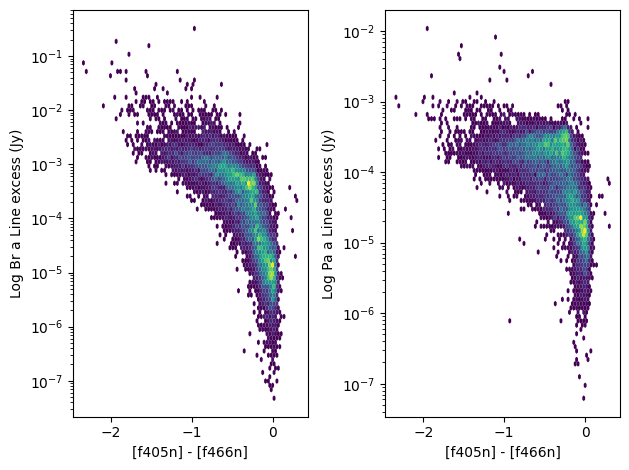

In [18]:
ax = plt.subplot(121)
mask = (bra_excess_dered > 0) & (paa_excess_dered > 0) & (cat_use.catalog['emag_ab_f182m'] < 0.05) & (cat_use.catalog['emag_ab_f212n'] < 0.05)

ax.hexbin(cat_use.color('f405n', 'f466n')[mask], bra_excess_dered[mask], gridsize=75, xscale='linear', yscale='log', cmap='viridis', mincnt=1, edgecolors='none')
ax.set_xlabel('[f405n] - [f466n]')
ax.set_ylabel('Log Br a Line excess (Jy)')

ax = plt.subplot(122)

ax.hexbin(cat_use.color('f405n', 'f466n')[mask], paa_excess_dered[mask], gridsize=75, xscale='linear', yscale='log', cmap='viridis', mincnt=1, edgecolors='none')
ax.set_xlabel('[f405n] - [f466n]')
ax.set_ylabel('Log Pa a Line excess (Jy)')

plt.tight_layout()

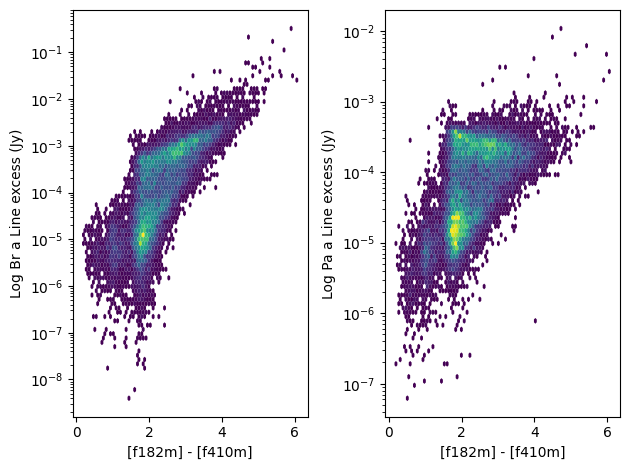

In [19]:
ax = plt.subplot(121)
mask = (bra_excess_dered > 0) & (paa_excess_dered > 0) & (cat_use.catalog['emag_ab_f182m'] < 0.05) & (cat_use.catalog['emag_ab_f212n'] < 0.05)

ax.hexbin(cat_use.color('f182m', 'f410m')[mask], bra_excess_dered[mask], gridsize=75, xscale='linear', yscale='log', cmap='viridis', mincnt=1, edgecolors='none')
ax.set_xlabel('[f182m] - [f410m]')
ax.set_ylabel('Log Br a Line excess (Jy)')

ax = plt.subplot(122)

ax.hexbin(cat_use.color('f182m', 'f410m')[mask], paa_excess_dered[mask], gridsize=75, xscale='linear', yscale='log', cmap='viridis', mincnt=1, edgecolors='none')
ax.set_xlabel('[f182m] - [f410m]')
ax.set_ylabel('Log Pa a Line excess (Jy)')

plt.tight_layout()

In [20]:
cat_use.catalog[:10]

skycoord_ref,skycoord_ref_filtername,sep_f410m,id_f410m,skycoord_f410m,flux_f410m,flux_err_f410m,mask_f410m,qfit_f410m,cfit_f410m,flux_init_f410m,flags_f410m,local_bkg_f410m,group_size_f410m,dra_f410m,ddec_f410m,std_ra_f410m,std_dec_f410m,nmatch_f410m,nmatch_good_f410m,flux_err_prop_f410m,flux_jy_f410m,mag_ab_f410m,eflux_jy_f410m,emag_ab_f410m,near_saturated_f410m_f410m,replaced_saturated_f410m,sep_f212n,id_f212n,skycoord_f212n,flux_f212n,flux_err_f212n,mask_f212n,qfit_f212n,cfit_f212n,flux_init_f212n,flags_f212n,local_bkg_f212n,group_size_f212n,dra_f212n,ddec_f212n,std_ra_f212n,std_dec_f212n,nmatch_f212n,nmatch_good_f212n,flux_err_prop_f212n,flux_jy_f212n,mag_ab_f212n,eflux_jy_f212n,emag_ab_f212n,near_saturated_f212n_f212n,replaced_saturated_f212n,sep_f466n,id_f466n,skycoord_f466n,flux_f466n,flux_err_f466n,mask_f466n,qfit_f466n,cfit_f466n,flux_init_f466n,flags_f466n,local_bkg_f466n,group_size_f466n,dra_f466n,ddec_f466n,std_ra_f466n,std_dec_f466n,nmatch_f466n,nmatch_good_f466n,flux_err_prop_f466n,flux_jy_f466n,mag_ab_f466n,eflux_jy_f466n,emag_ab_f466n,near_saturated_f466n_f466n,replaced_saturated_f466n,sep_f405n,id_f405n,skycoord_f405n,flux_f405n,flux_err_f405n,mask_f405n,qfit_f405n,cfit_f405n,flux_init_f405n,flags_f405n,local_bkg_f405n,group_size_f405n,dra_f405n,ddec_f405n,std_ra_f405n,std_dec_f405n,nmatch_f405n,nmatch_good_f405n,flux_err_prop_f405n,flux_jy_f405n,mag_ab_f405n,eflux_jy_f405n,emag_ab_f405n,near_saturated_f405n_f405n,replaced_saturated_f405n,sep_f187n,id_f187n,skycoord_f187n,flux_f187n,flux_err_f187n,mask_f187n,qfit_f187n,cfit_f187n,flux_init_f187n,flags_f187n,local_bkg_f187n,group_size_f187n,dra_f187n,ddec_f187n,std_ra_f187n,std_dec_f187n,nmatch_f187n,nmatch_good_f187n,flux_err_prop_f187n,flux_jy_f187n,mag_ab_f187n,eflux_jy_f187n,emag_ab_f187n,near_saturated_f187n_f187n,replaced_saturated_f187n,sep_f182m,id_f182m,skycoord_f182m,flux_f182m,flux_err_f182m,mask_f182m,qfit_f182m,cfit_f182m,flux_init_f182m,flags_f182m,local_bkg_f182m,group_size_f182m,dra_f182m,ddec_f182m,std_ra_f182m,std_dec_f182m,nmatch_f182m,nmatch_good_f182m,flux_err_prop_f182m,flux_jy_f182m,mag_ab_f182m,eflux_jy_f182m,emag_ab_f182m,near_saturated_f182m_f182m,replaced_saturated_f182m,flux_jy_410m405,mag_ab_410m405,flux_jy_405m410,mag_ab_405m410,flux_jy_182m187,mag_ab_182m187,flux_jy_187m182,mag_ab_187m182
"deg,deg",,deg,,"deg,deg",,,,,,,,,,,,deg,deg,,,,Jy,mag,Jy,mag,,,deg,,"deg,deg",,,,,,,,,,,,deg,deg,,,,Jy,mag,Jy,mag,,,deg,,"deg,deg",,,,,,,,,,,,deg,deg,,,,Jy,mag,Jy,mag,,,deg,,"deg,deg",,,,,,,,,,,,deg,deg,,,,Jy,mag,Jy,mag,,,deg,,"deg,deg",,,,,,,,,,,,deg,deg,,,,Jy,mag,Jy,mag,,,deg,,"deg,deg",,,,,,,,,,,,deg,deg,,,,Jy,mag,Jy,mag,,,Jy,Jy,Jy,Jy,Jy,Jy,Jy,Jy
SkyCoord,bytes5,float64,int64,SkyCoord,float64,float64,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,float64,bool,bool,float64,int64,SkyCoord,float64,float64,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,float64,bool,bool,float64,int64,SkyCoord,float64,float64,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,float64,bool,bool,float64,int64,SkyCoord,float64,float64,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,float64,bool,bool,float64,int64,SkyCoord,float64,float64,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,float64,bool,bool,float64,int64,SkyCoord,float64,float64,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,float64,bool,bool,float64,float64,float64,float64,float64,float64,float64,float64
"266.6059560209768,-28.576739545404976",f405n,2.600050326008066e-06,4119,"266.60595789823896,-28.576737534812466",181.386266

(22.0, 14.5)

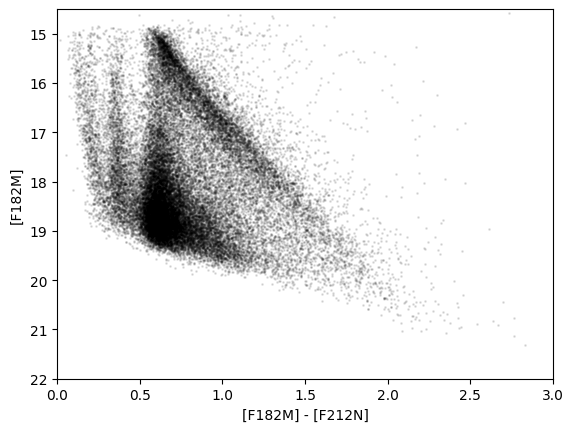

In [21]:
cat_use.plot_CMD('f182m', 'f212n', 'f182m', s=1, color='k', alpha=0.1)
plt.xlim(0, 3)
plt.ylim(22, 14.5)

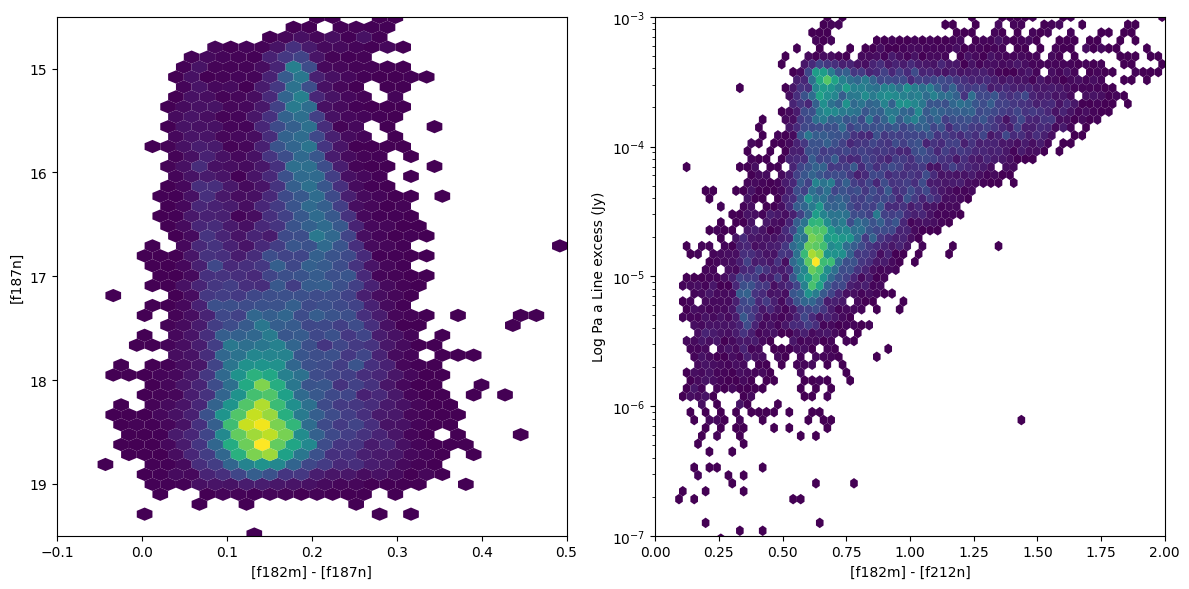

In [22]:
fig = plt.figure(figsize=(12, 6))
#cat_use.plot_CMD('f182m', 'f187n', 'f187n', s=1, color='k', alpha=0.1)
ax = plt.subplot(121)
ax.hexbin(cat_use.color('f182m', 'f187n'), cat_use.band('f187n'), gridsize=75, xscale='linear', yscale='linear', cmap='viridis', mincnt=1, edgecolors='none')
ax.set_xlim(-0.1, 0.5)
ax.set_ylim(19.5, 14.5)
ax.set_xlabel('[f182m] - [f187n]')
ax.set_ylabel('[f187n]')
#ax.set_title('Cloud C')

ax = plt.subplot(122)

ax.hexbin(cat_use.color('f182m', 'f212n')[mask], paa_excess_dered[mask], gridsize=75, xscale='linear', yscale='log', cmap='viridis', mincnt=1, edgecolors='none')
ax.set_xlabel('[f182m] - [f212n]')
ax.set_ylabel('Log Pa a Line excess (Jy)')
ax.set_xlim(0, 2)
ax.set_ylim(10**-7, 10**-3)

plt.tight_layout()

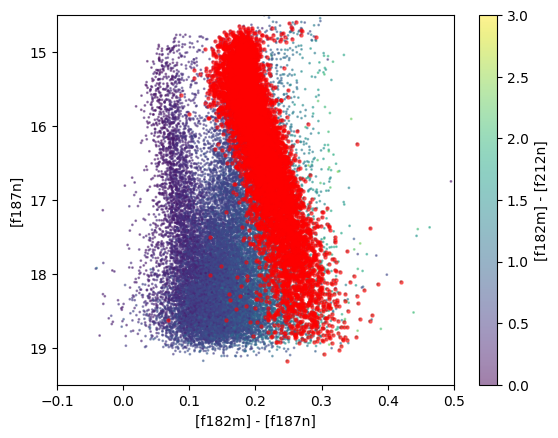

In [29]:
ax = plt.subplot(111)
#ax.hexbin(cat_use.color('f182m', 'f187n'), cat_use.band('f187n'), gridsize=75, xscale='linear', yscale='linear', cmap='viridis', mincnt=1, edgecolors='none')
im = ax.scatter(cat_use.color('f182m', 'f187n'), cat_use.band('f187n'), s=1, alpha=0.5, c=cat_use.color('f182m', 'f212n'), cmap='viridis', vmin=0, vmax=3)
ax.scatter(cat_rc.color('f182m', 'f187n'), cat_rc.band('f187n'), s=5, alpha=0.5, color='red')
ax.set_xlim(-0.1, 0.5)
ax.set_ylim(19.5, 14.5)
ax.set_xlabel('[f182m] - [f187n]')
ax.set_ylabel('[f187n]')
plt.colorbar(im, label='[f182m] - [f212n]')

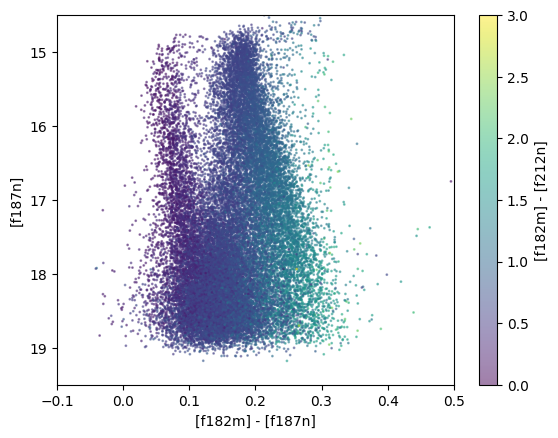

In [36]:
ax = plt.subplot(111)
#ax.hexbin(cat_use.color('f182m', 'f187n'), cat_use.band('f187n'), gridsize=75, xscale='linear', yscale='linear', cmap='viridis', mincnt=1, edgecolors='none')
im = ax.scatter(cat_use.color('f182m', 'f187n'), cat_use.band('f187n'), s=1, alpha=0.5, c=cat_use.color('f182m', 'f212n'), cmap='viridis', vmin=0, vmax=3)
#ax.scatter(cat_rc.color('f182m', 'f187n'), cat_rc.band('f187n'), s=5, alpha=0.5, color='red')
ax.set_xlim(-0.1, 0.5)
ax.set_ylim(19.5, 14.5)
ax.set_xlabel('[f182m] - [f187n]')
ax.set_ylabel('[f187n]')
plt.colorbar(im, label='[f182m] - [f212n]')

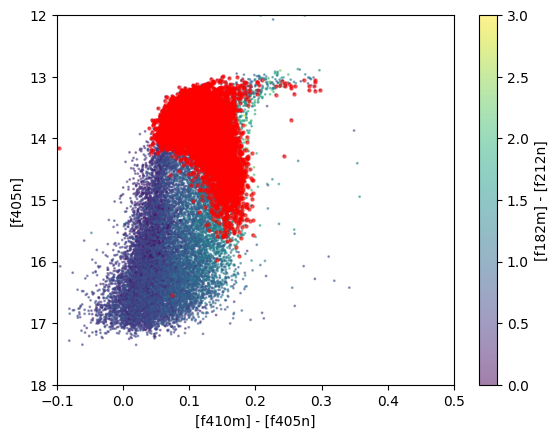

In [35]:
ax = plt.subplot(111)
#ax.hexbin(cat_use.color('f182m', 'f187n'), cat_use.band('f187n'), gridsize=75, xscale='linear', yscale='linear', cmap='viridis', mincnt=1, edgecolors='none')
im = ax.scatter(cat_use.color('f410m', 'f405n'), cat_use.band('f405n'), s=1, alpha=0.5, c=cat_use.color('f182m', 'f212n'), cmap='viridis', vmin=0, vmax=3)
ax.scatter(cat_rc.color('f410m', 'f405n'), cat_rc.band('f405n'), s=5, alpha=0.5, color='red')
ax.set_xlim(-0.1, 0.5)
ax.set_ylim(18, 12)
ax.set_xlabel('[f410m] - [f405n]')
ax.set_ylabel('[f405n]')
plt.colorbar(im, label='[f182m] - [f212n]')

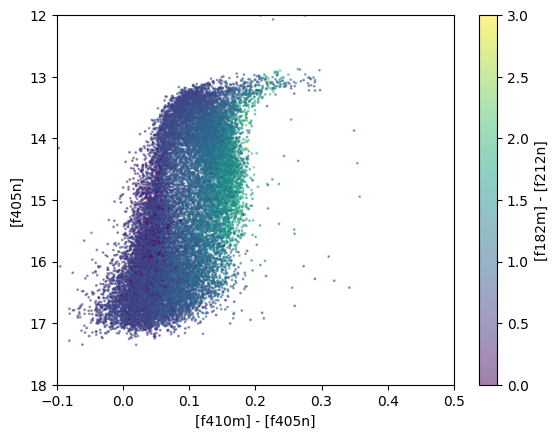

In [34]:
ax = plt.subplot(111)
#ax.hexbin(cat_use.color('f182m', 'f187n'), cat_use.band('f187n'), gridsize=75, xscale='linear', yscale='linear', cmap='viridis', mincnt=1, edgecolors='none')
im = ax.scatter(cat_use.color('f410m', 'f405n'), cat_use.band('f405n'), s=1, alpha=0.5, c=cat_use.color('f182m', 'f212n'), cmap='viridis', vmin=0, vmax=3)
#ax.scatter(cat_rc.color('f410m', 'f405n'), cat_rc.band('f405n'), s=5, alpha=0.5, color='red')
ax.set_xlim(-0.1, 0.5)
ax.set_ylim(18, 12)
ax.set_xlabel('[f410m] - [f405n]')
ax.set_ylabel('[f405n]')
plt.colorbar(im, label='[f182m] - [f212n]')